# Meta-Learners

En este capítulo exploraremos los meta-learners, una familia de métodos que permiten estimar efectos causales heterogéneos (CATE) utilizando algoritmos de machine learning convencionales. El objetivo principal será entender cómo diferentes unidades responden de manera distinta al tratamiento, lo que resulta esencial cuando no podemos tratar a todos y debemos priorizar, como en campañas de descuentos con presupuesto limitado.

Primero, repasaremos la motivación detrás de la estimación de efectos heterogéneos y su importancia práctica. Luego, veremos cómo los meta-learners (como el S-learner, T-learner y X-learner) reutilizan modelos predictivos para inferencia causal, permitiendo abordar datos de alta dimensión y relaciones complejas.

Finalmente, aprenderemos a implementar estos métodos en Python, discutiendo sus ventajas, limitaciones y cómo elegir el algoritmo de machine learning más adecuado para cada caso.


In [1]:
import polars as pl
import numpy as np
from plotnine import *

from fklearn.causal.validation.curves import relative_cumulative_gain_curve
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve

## Metalearners for Discrete Treatment

In [2]:
data_biased = pl.read_csv("../data/email_obs_data.csv")
data_rnd = pl.read_csv("../data/email_rnd_data.csv")

print(len(data_biased), len(data_rnd))
data_rnd.head()

300000 10000


mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,personal_care,toys,clothing,decor,cell_phones,construction,home_appliances,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,244.26,61.0,1.0,21.84,0,2,2,0,2,0,0,2,0,3,1,1,1,0,0,3,1,0,1,0,0,2
0,29.67,36.0,1.0,107.4,0,2,0,2,0,0,1,2,2,3,1,1,1,1,1,2,1,2,1,0,2,2
0,11.73,64.0,0.0,59.81,0,1,0,0,0,3,1,3,0,2,1,1,2,0,0,3,0,1,0,1,0,1
0,41.41,74.0,0.0,62.98,0,1,0,0,3,1,0,0,2,6,3,1,1,0,2,2,1,1,0,4,1,0
0,447.89,59.0,0.0,72.56,0,1,1,3,2,2,2,3,0,2,0,1,5,0,0,1,0,0,1,1,2,1


In [3]:
y = "next_mnth_pv"
T = "mkt_email"
X = list(data_rnd.drop([y, T]).columns)

## T-Learner

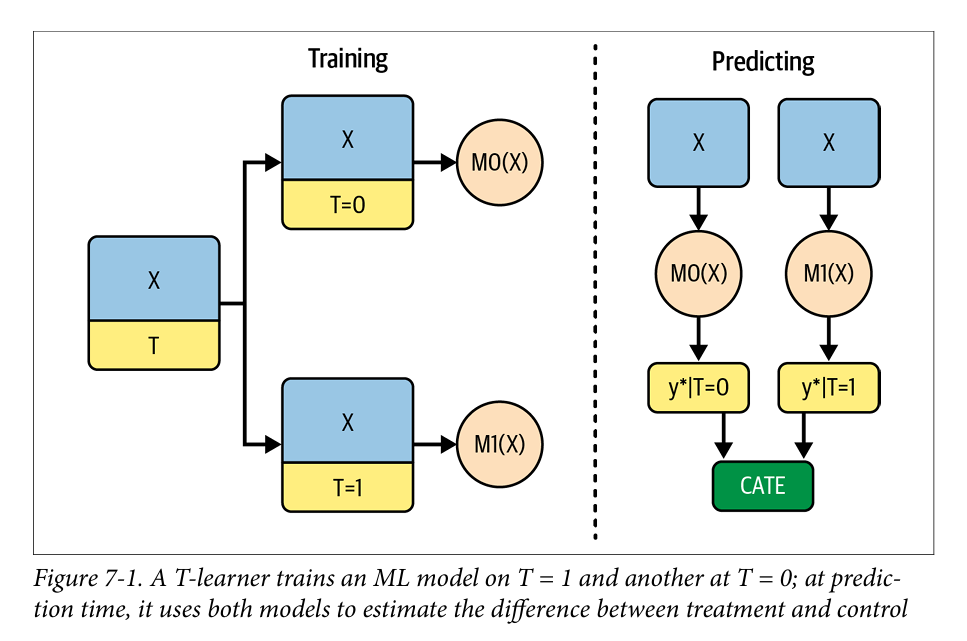

In [4]:
train, test = data_biased, data_rnd

In [5]:
from lightgbm import LGBMRegressor

np.random.seed(123)

m0 = LGBMRegressor()
m1 = LGBMRegressor()

m0.fit(train.filter(pl.col(T)==0).select(X).to_numpy(), 
       train.filter(pl.col(T)==0)
            .select(y).to_numpy().ravel())
m1.fit(train.filter(pl.col(T)==1).select(X).to_numpy(), 
       train.filter(pl.col(T)==1)
            .select(y).to_numpy().ravel())


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 146759, number of used features: 25
[LightGBM] [Info] Start training from score 88.249324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 153241, number of used features: 25
[LightGBM] [Info] Start training from score 1596.224063


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [6]:
t_learner_cate_test = test.with_columns(
    cate=pl.Series(m1.predict(test.select(X).to_numpy()) - 
                   m0.predict(test.select(X).to_numpy())
                )
)

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names


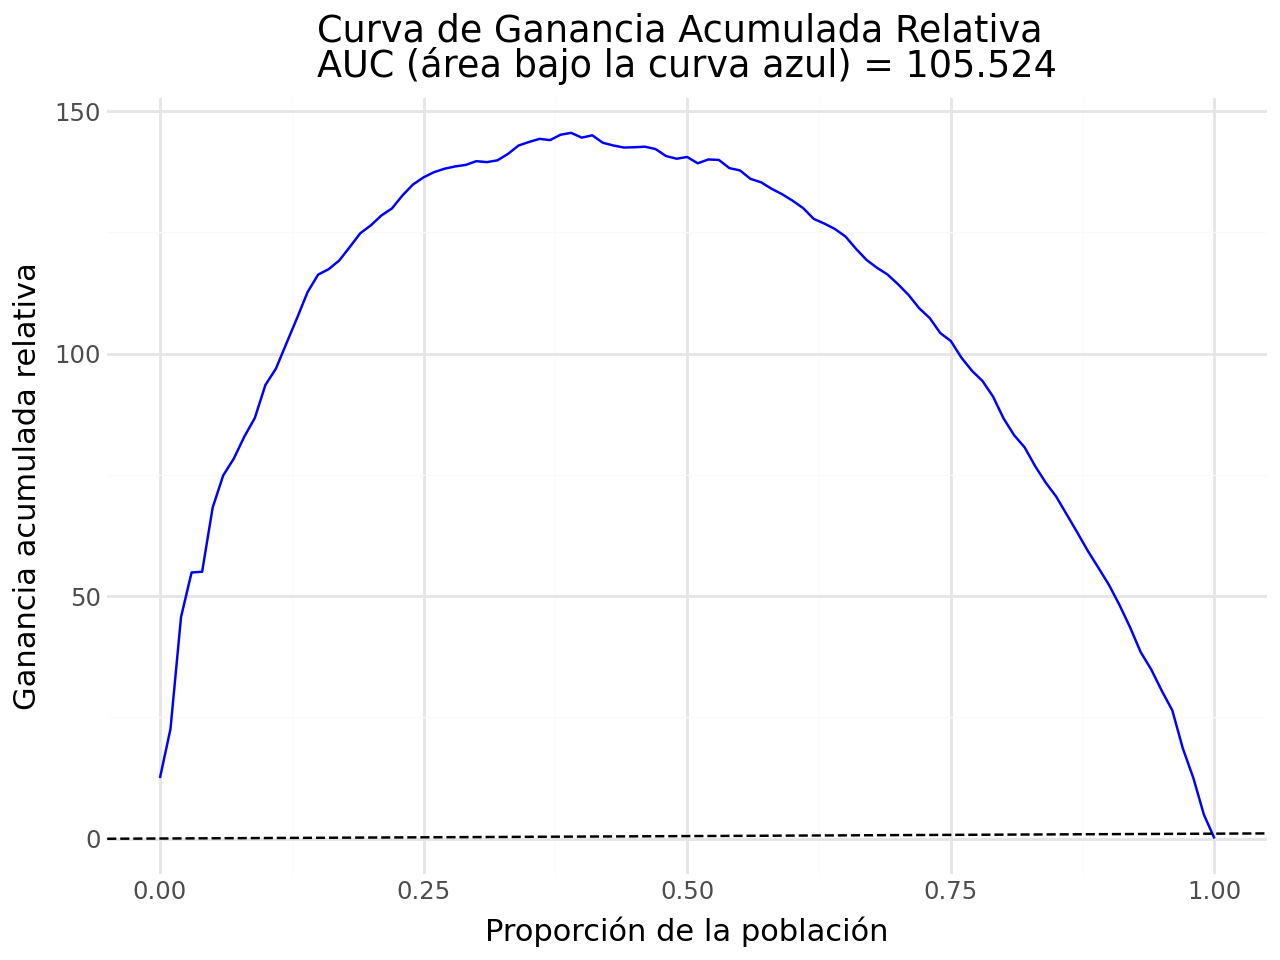

In [7]:
gain_curve_test = relative_cumulative_gain_curve(t_learner_cate_test.to_pandas(), T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(t_learner_cate_test.to_pandas(), T, y, prediction="cate")
gain_curve_test = pl.DataFrame(gain_curve_test, schema=["gain"])
x = np.linspace(0, 1, len(gain_curve_test))

# La curva azul representa el "Relative Cumulative Gain Curve", cuyo área bajo la curva (AUC) es nuestro estimador de performance causal. La línea punteada es el baseline (lo que esperaríamos si el modelo no tuviera poder predictivo causal).
# Nota: El valor de AUC está incluido en el título para facilitar la interpretación.

(
    ggplot(gain_curve_test) +
    geom_line(aes(x=x, y="gain"), color="blue") +  # Línea azul: curva de ganancia acumulada (AUC)
    geom_abline(slope=1, intercept=0, linetype="dashed") +  # Línea punteada: baseline (modelo aleatorio)
    labs(
        title=f"Curva de Ganancia Acumulada Relativa\nAUC (área bajo la curva azul) = {auc:.3f}",
        x="Proporción de la población",
        y="Ganancia acumulada relativa"
    ) +
    theme_minimal()
)

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names


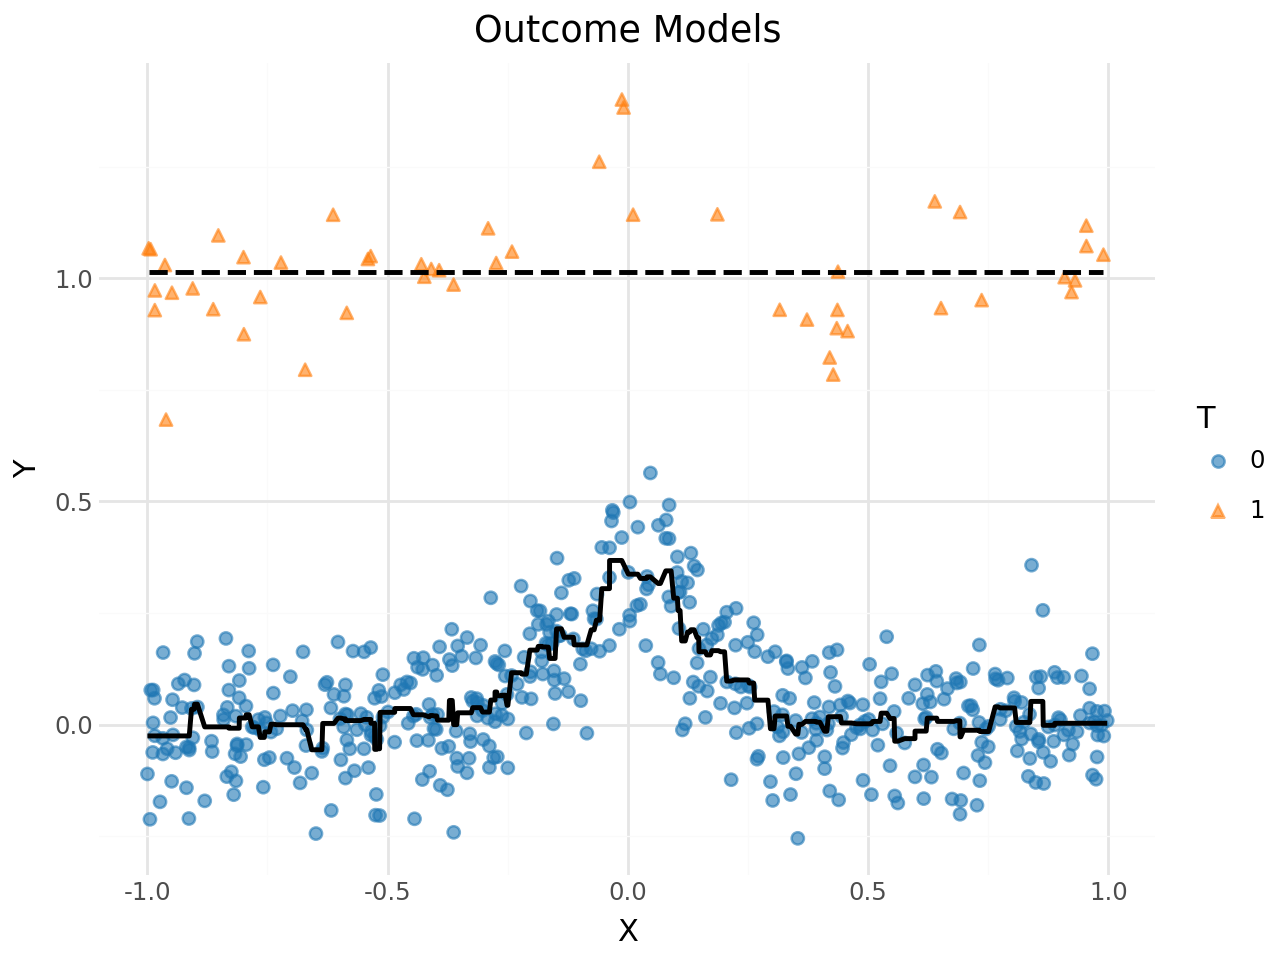

In [8]:
import numpy as np
import polars as pl
from lightgbm import LGBMRegressor
from plotnine import *

# Configuración de semilla
np.random.seed(123)

# Definición del Kernel
def g_kernel(x, c=0, s=0.05): 
    return np.exp((-(x-c)**2)/s)

# Generación de datos (T=0)
n0 = 500
x0 = np.random.uniform(-1, 1, n0)
y0 = np.random.normal(0.3*g_kernel(x0), 0.1, n0)

# Generación de datos (T=1)
n1 = 50
x1 = np.random.uniform(-1, 1, n1)
y1 = np.random.normal(0.3*g_kernel(x1), 0.1, n1) + 1

# Creación del DataFrame con Polars
df = pl.concat([
    pl.DataFrame({"x": x0, "y": y0, "t": 0}), 
    pl.DataFrame({"x": x1, "y": y1, "t": 1})
]).sort("x")

# Entrenamiento de Modelos (LGBM requiere arrays de numpy, reshape necesario para X)
m0 = LGBMRegressor(min_child_samples=25, verbose=-1)
m1 = LGBMRegressor(min_child_samples=25, verbose=-1)

# Fit (usamos numpy directo ya que LGBM es nativo con numpy)
m0.fit(x0.reshape(-1, 1), y0)
m1.fit(x1.reshape(-1, 1), y1)

# Predicciones para todo el rango (necesario para las líneas y el CATE)
# Convertimos la columna x a numpy reshapeado para predecir
x_all = df["x"].to_numpy().reshape(-1, 1)

# Añadimos las predicciones y cálculos de efectos al DataFrame
df = df.with_columns([
    pl.Series(m0.predict(x_all)).alias("mu0_hat"),
    pl.Series(m1.predict(x_all)).alias("mu1_hat")
]).with_columns([
    (pl.col("mu1_hat") - pl.col("mu0_hat")).alias("cate_hat"),
    # Cálculo de tau (proxy del efecto individual)
    # Si t=0: tau = m1(x) - y
    # Si t=1: tau = y - m0(x)
    pl.when(pl.col("t") == 0)
      .then(pl.col("mu1_hat") - pl.col("y"))
      .otherwise(pl.col("y") - pl.col("mu0_hat"))
      .alias("tau_hat")
])

# Conversión de 't' a factor para el ploteo correcto de colores
df = df.with_columns(pl.col("t").cast(pl.Utf8).alias("t_factor"))

# ---------------------------------------------------------
# GRÁFICO 1: Datos y Regresiones
# ---------------------------------------------------------
(
    ggplot(df, aes(x="x"))
    # Scatter de puntos observados
    + geom_point(aes(y="y", color="t_factor", shape="t_factor"), alpha=0.6, size=2)
    # Línea mu0 (solo donde t=0 para replicar lógica original, o todo el rango si prefieres)
    + geom_line(df.filter(pl.col("t") == 0), aes(y="mu0_hat"), color="black", linetype="solid", size=1)
    # Línea mu1
    + geom_line(df.filter(pl.col("t") == 1), aes(y="mu1_hat"), color="black", linetype="dashed", size=1)
    + labs(y="Y", x="X", color="T", shape="T", title="Outcome Models")
    + scale_color_manual(values=["#1f77b4", "#ff7f0e"]) # Colores tipo matplotlib por defecto
    + theme_minimal()
)





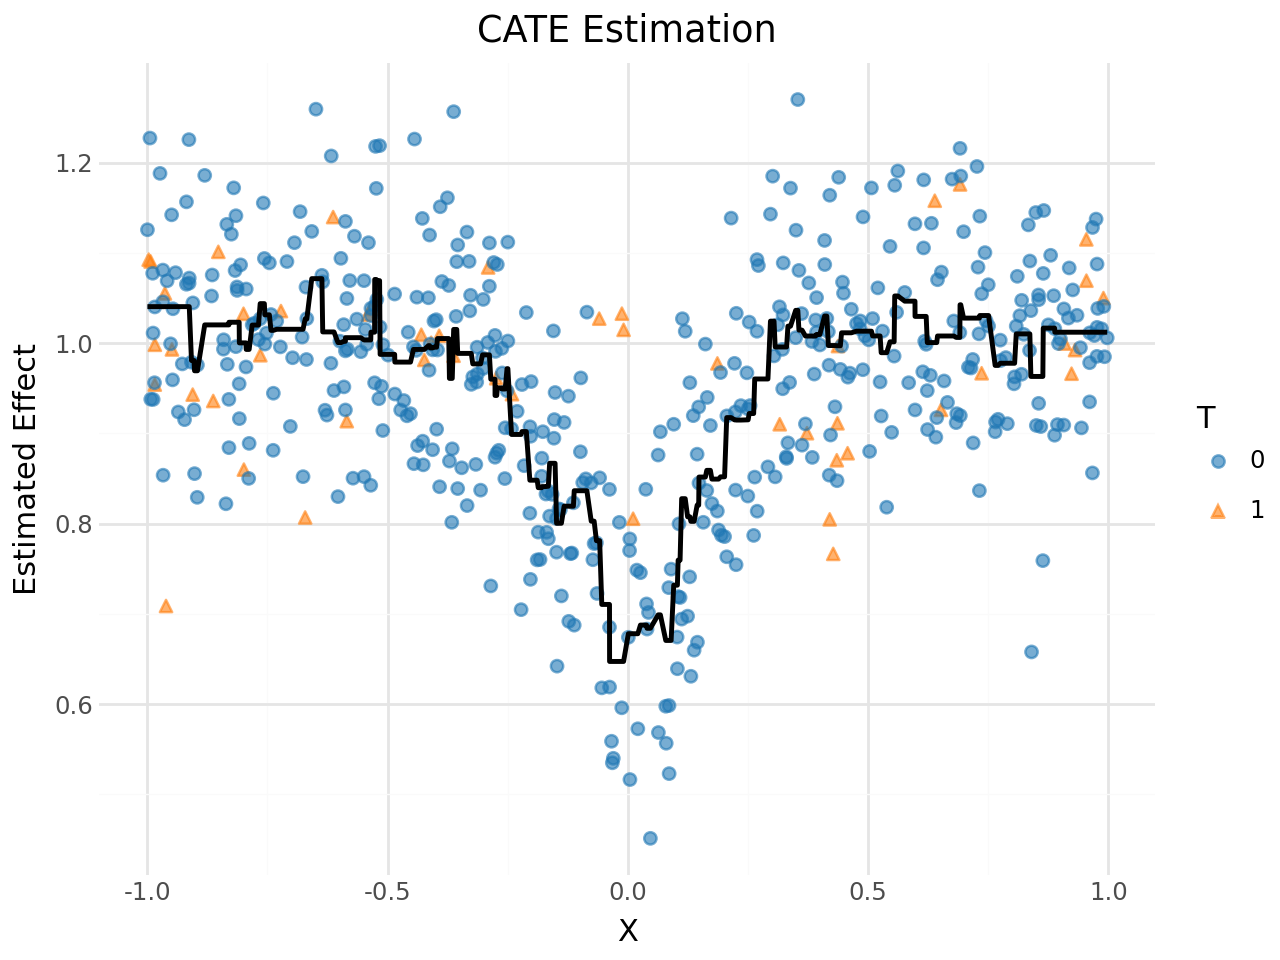

In [9]:
# ---------------------------------------------------------
# GRÁFICO 2: Efecto Estimado (CATE)
# ---------------------------------------------------------
(
    ggplot(df, aes(x="x"))
    # Scatter de efectos individuales estimados (tau)
    + geom_point(aes(y="tau_hat", color="t_factor", shape="t_factor"), alpha=0.6, size=2)
    # Línea del CATE (sobre todo el rango X)
    + geom_line(aes(y="cate_hat"), color="black", size=1)
    + labs(y="Estimated Effect", x="X", color="T", shape="T", title="CATE Estimation")
    + scale_color_manual(values=["#1f77b4", "#ff7f0e"])
    + theme_minimal()
)

## X-Learner

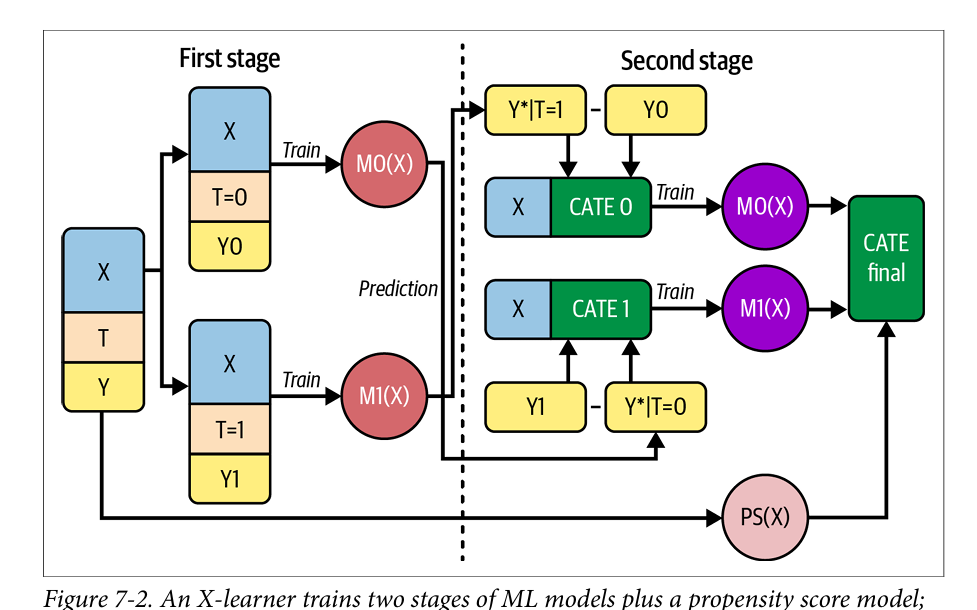

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names


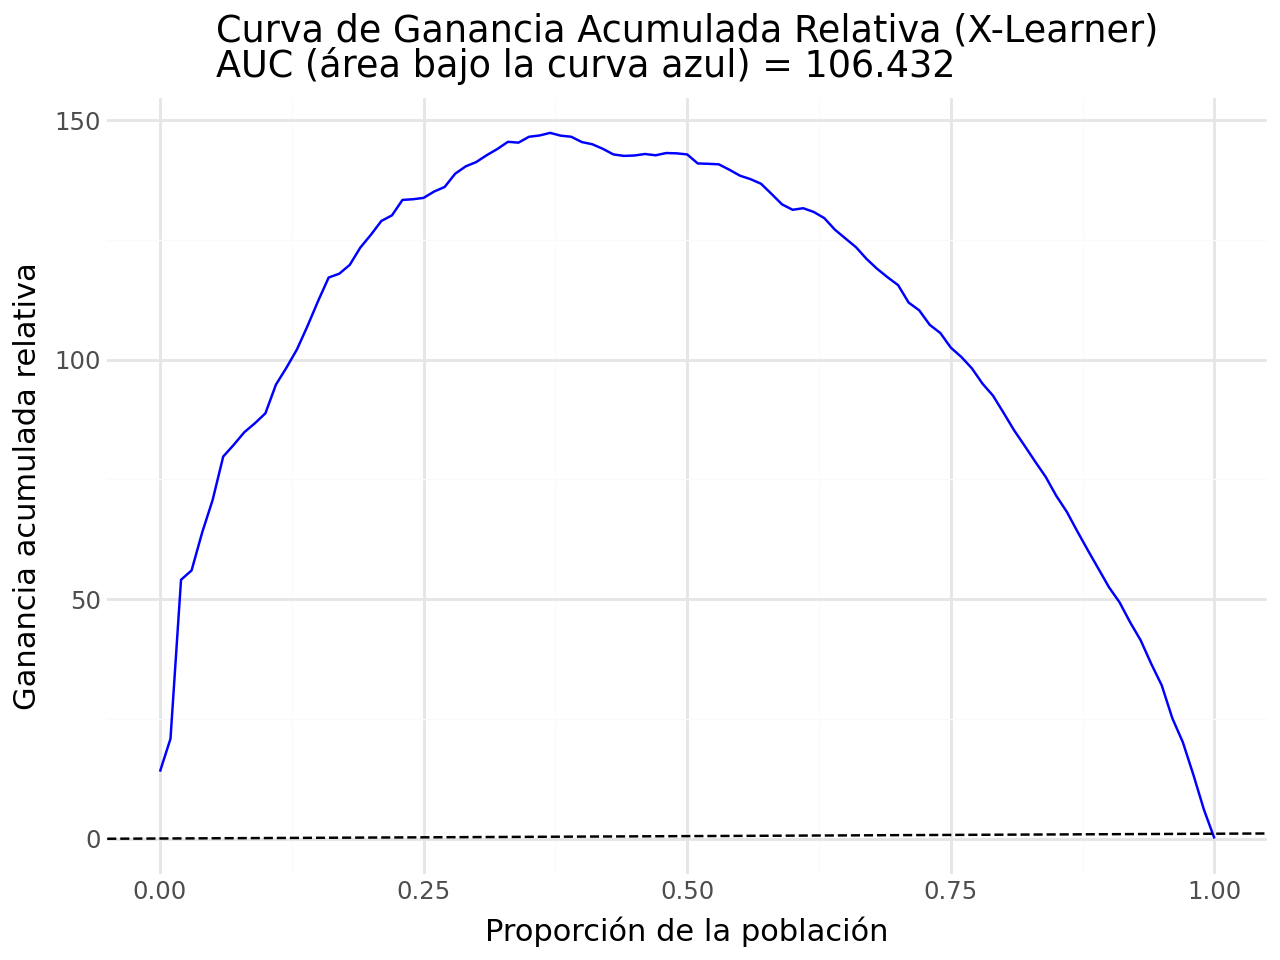

In [ ]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor

# Propensity Score Model
ps_model = LogisticRegression(penalty=None)
ps_model.fit(
    train.select(X).to_numpy(), 
    train.select(T).to_numpy().ravel()
)

# first stage models
train_t0 = train.filter(pl.col(T) == 0)
train_t1 = train.filter(pl.col(T) == 1)

m0 = LGBMRegressor()
m1 = LGBMRegressor()

np.random.seed(123)

m0.fit(
    train_t0.select(X).to_numpy(), 
    train_t0.select(y).to_numpy().ravel(),
    sample_weight=1/ps_model.predict_proba(train_t0.select(X).to_numpy())[:, 0]
)

m1.fit(
    train_t1.select(X).to_numpy(), 
    train_t1.select(y).to_numpy().ravel(),
    sample_weight=1 / ps_model.predict_proba(train_t1.select(X).to_numpy())[:,1]
)

# Second Stage

tau_hat_0 = m1.predict(train_t0.select(X).to_numpy()) - train_t0.select(y).to_numpy().ravel()
tau_hat_1 = train_t1.select(y).to_numpy().ravel() - m0.predict(train_t1.select(X).to_numpy())

m_tau_0 = LGBMRegressor()
m_tau_1 = LGBMRegressor()

np.random.seed(123)

m_tau_0.fit(train_t0.select(X).to_numpy(), tau_hat_0)
m_tau_1.fit(train_t1.select(X).to_numpy(), tau_hat_1)

# Estimate CATE on test set
ps_test = ps_model.predict_proba(test.select(X).to_numpy())[:,1]

x_cate_test = test.with_columns(
    cate=pl.Series(
        ps_test * m_tau_1.predict(test.select(X).to_numpy()) + 
        (1 - ps_test) * m_tau_0.predict(test.select(X).to_numpy()
    )
))

gain_curve_test = relative_cumulative_gain_curve(x_cate_test.to_pandas(), T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(x_cate_test.to_pandas(), T, y, prediction="cate")
gain_curve_test = pl.DataFrame(gain_curve_test, schema=["gain"])
x = np.linspace(0, 1, len(gain_curve_test))

(
    ggplot(gain_curve_test) +
    geom_line(aes(x=x, y="gain"), color="blue") +  # Línea azul: curva de ganancia acumulada (AUC)
    geom_abline(slope=1, intercept=0, linetype="dashed") +  # Línea punteada: baseline (modelo aleatorio)
    labs(
        title=f"Curva de Ganancia Acumulada Relativa (X-Learner)\nAUC (área bajo la curva azul) = {auc:.3f}",
        x="Proporción de la población",
        y="Ganancia acumulada relativa"
    ) +
    theme_minimal()
)

## Metalearners for Continuous Treatments

In [16]:
data_cont = pl.read_csv("../data/discount_data.csv")
data_cont.head()

rest_id,day,month,weekday,weekend,is_holiday,is_dec,is_nov,competitors_price,discounts,sales
i64,str,i64,i64,bool,bool,bool,bool,f64,i64,f64
0,"""2016-01-01""",1,4,false,true,false,false,2.88,0,79.0
0,"""2016-01-02""",1,5,true,false,false,false,2.64,0,57.0
0,"""2016-01-03""",1,6,true,false,false,false,2.08,5,294.0
0,"""2016-01-04""",1,0,false,false,false,false,3.37,15,676.5
0,"""2016-01-05""",1,1,false,false,false,false,3.79,0,66.0


In [17]:
train = data_cont.filter(pl.col("day") <'2018-01-01')
test = data_cont.filter(pl.col("day") >= '2018-01-01')

## S-Learner

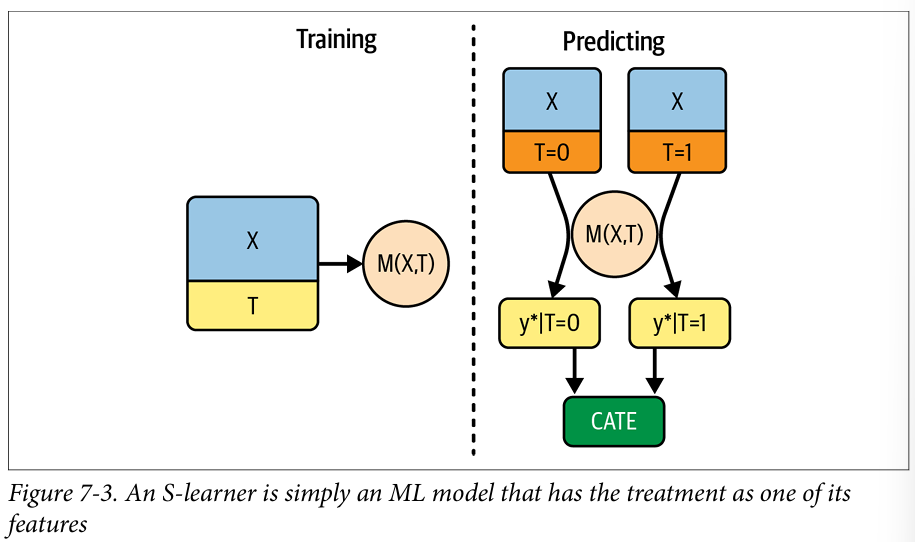

In [25]:
X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

np.random.seed(123)
s_learner = LGBMRegressor()
s_learner.fit(
    train.select(X + [T]).to_numpy(), 
    train.select(y).to_numpy().ravel()
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20
